# Fruit Grading System — Final (v6)

**Real fruit dataset locked in. Run all → upload fruit picture → get grade.**

Dataset: [`Densu341/Fresh-rotten-fruit`](https://huggingface.co/datasets/Densu341/Fresh-rotten-fruit)
(30,400 real fruit photos, 22 classes — fresh and rotten apples, bananas, grapes, oranges, etc.)

**Two things to do once:**
1. Runtime → Change runtime type → **T4 GPU**
2. Runtime → **Run all**

Then when cell 5 asks, upload a fruit picture. You'll get output like *Grade A — Fresh Apples (92.3% confidence)*.

## 1. Install dependencies

In [3]:
!pip -q install tensorflow==2.15.0 datasets pillow numpy matplotlib 2>/dev/null
print('deps installed')

deps installed


## 2. Download the real fruit dataset and stage it on disk

Pulls 10,000 balanced samples from Hugging Face and writes them into `/content/dataset/<class>/*.jpg` so Keras can train on it. Takes ~3 minutes.

In [4]:
import os, shutil, re
from pathlib import Path
from datasets import load_dataset

OUT = Path('/content/dataset')
if OUT.exists(): shutil.rmtree(OUT)
OUT.mkdir(parents=True, exist_ok=True)

print('Loading dataset metadata from Hugging Face...')
ds = load_dataset('Densu341/Fresh-rotten-fruit', split='train')
print(f'Total images available: {len(ds)}')
print(f'Columns: {ds.column_names}')
feat = ds.features['label']
raw_classes = feat.names if hasattr(feat, 'names') else None
print(f'Classes ({len(raw_classes)}):')
for i, n in enumerate(raw_classes): print(f'  {i:2d}: {n}')

PER_CLASS = 500   # 500 imgs × 22 classes ≈ 11k images → fast & accurate enough
print(f'\nShuffling and writing {PER_CLASS} images per class to disk...')
ds = ds.shuffle(seed=42)
counts = {i: 0 for i in range(len(raw_classes))}
for i, row in enumerate(ds):
    lbl = row['label']
    if counts[lbl] >= PER_CLASS: continue
    cls_name = raw_classes[lbl]
    folder = OUT / cls_name
    folder.mkdir(parents=True, exist_ok=True)
    try:
        row['image'].convert('RGB').save(folder / f'{counts[lbl]:04d}.jpg', 'JPEG', quality=85)
        counts[lbl] += 1
    except Exception as e:
        pass
    if all(c >= PER_CLASS for c in counts.values()): break
    if i % 1000 == 0:
        done = sum(min(c, PER_CLASS) for c in counts.values())
        print(f'  staged {done}/{PER_CLASS*len(raw_classes)} images...')

total = sum(1 for _ in OUT.rglob('*.jpg'))
print(f'\nDone. {total} images written to {OUT} across {len(list(OUT.iterdir()))} class folders.')

Loading dataset metadata from Hugging Face...
Total images available: 30357
Columns: ['image', 'label']
Classes (22):
   0: freshapples
   1: freshbanana
   2: freshbittergroud
   3: freshcapsicum
   4: freshcucumber
   5: freshokra
   6: freshoranges
   7: freshpatato
   8: freshpotato
   9: freshtamto
  10: freshtomato
  11: rottenapples
  12: rottenbanana
  13: rottenbittergroud
  14: rottencapsicum
  15: rottencucumber
  16: rottenokra
  17: rottenoranges
  18: rottenpatato
  19: rottenpotato
  20: rottentamto
  21: rottentomato

Shuffling and writing 500 images per class to disk...
  staged 1/11000 images...
  staged 1001/11000 images...
  staged 2001/11000 images...
  staged 3001/11000 images...
  staged 3937/11000 images...
  staged 4581/11000 images...
  staged 6117/11000 images...
  staged 8926/11000 images...
  staged 9050/11000 images...

Done. 9932 images written to /content/dataset across 22 class folders.


## 3. Train the grader

MobileNetV2 backbone (ImageNet) + custom head fine-tuned on the fruit data. ~5 minutes on T4 GPU. Expect ~90%+ validation accuracy.

In [5]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

INPUT_SIZE = (224, 224); BATCH = 32
train_ds = tf.keras.utils.image_dataset_from_directory(
    OUT, validation_split=0.2, subset='training', seed=42,
    image_size=INPUT_SIZE, batch_size=BATCH)
val_ds = tf.keras.utils.image_dataset_from_directory(
    OUT, validation_split=0.2, subset='validation', seed=42,
    image_size=INPUT_SIZE, batch_size=BATCH)

RAW_CLASS_NAMES = train_ds.class_names

# Clean raw names ("0freshapples" -> "Fresh Apples") and assign quality grade.
def clean_and_grade(raw):
    name = re.sub(r'^\d+', '', raw).strip()  # strip leading digits
    n = name.lower()
    if 'fresh' in n:
        fruit = name[name.lower().find('fresh')+5:].title()
        return 'Grade A', f'Fresh {fruit}'
    if 'rotten' in n or 'stale' in n:
        kw_pos = max(n.find('rotten'), n.find('stale'))
        kw_len = 6 if 'rotten' in n else 5
        fruit = name[kw_pos+kw_len:].title()
        return 'Grade C', f'Rotten {fruit}'
    return 'Grade B', name.title()

GRADES, FRUITS, DISPLAY = [], [], []
for r in RAW_CLASS_NAMES:
    g, f = clean_and_grade(r)
    GRADES.append(g); FRUITS.append(f); DISPLAY.append(f'{g} — {f}')

print('Class mapping:')
for r, d in zip(RAW_CLASS_NAMES, DISPLAY):
    print(f'  {r:25s} -> {d}')

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(2000).prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)

base = tf.keras.applications.MobileNetV2(
    input_shape=INPUT_SIZE+(3,), include_top=False, weights='imagenet')
base.trainable = False
inp = tf.keras.Input(shape=INPUT_SIZE+(3,))
x = tf.keras.applications.mobilenet_v2.preprocess_input(inp)
x = base(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.2)(x)
out = tf.keras.layers.Dense(len(RAW_CLASS_NAMES), activation='softmax')(x)
MODEL = tf.keras.Model(inp, out)
MODEL.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print('\nStage 1: train classifier head (5 epochs)')
MODEL.fit(train_ds, validation_data=val_ds, epochs=5)

print('\nStage 2: fine-tune last 30 backbone layers (3 epochs)')
base.trainable = True
for l in base.layers[:-30]: l.trainable = False
MODEL.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
              loss='sparse_categorical_crossentropy', metrics=['accuracy'])
h2 = MODEL.fit(train_ds, validation_data=val_ds, epochs=3)
print(f'\n>>> Final validation accuracy: {h2.history["val_accuracy"][-1]*100:.1f}%')
MODEL.save('/content/fruit_grader.keras')
print('Model saved to /content/fruit_grader.keras')

Found 9932 files belonging to 22 classes.
Using 7946 files for training.
Found 9932 files belonging to 22 classes.
Using 1986 files for validation.
Class mapping:
  freshapples               -> Grade A — Fresh Apples
  freshbanana               -> Grade A — Fresh Banana
  freshbittergroud          -> Grade A — Fresh Bittergroud
  freshcapsicum             -> Grade A — Fresh Capsicum
  freshcucumber             -> Grade A — Fresh Cucumber
  freshokra                 -> Grade A — Fresh Okra
  freshoranges              -> Grade A — Fresh Oranges
  freshpatato               -> Grade A — Fresh Patato
  freshpotato               -> Grade A — Fresh Potato
  freshtamto                -> Grade A — Fresh Tamto
  freshtomato               -> Grade A — Fresh Tomato
  rottenapples              -> Grade C — Rotten Apples
  rottenbanana              -> Grade C — Rotten Banana
  rottenbittergroud         -> Grade C — Rotten Bittergroud
  rottencapsicum            -> Grade C — Rotten Capsicum
  rottenc

## 4. Predict helper

In [6]:
def predict_image(img_path):
    img = Image.open(img_path).convert('RGB')
    arr = np.asarray(img.resize(INPUT_SIZE)).astype('float32')
    probs = MODEL.predict(np.expand_dims(arr, 0), verbose=0)[0]
    top = int(np.argmax(probs))
    grade = GRADES[top]; fruit = FRUITS[top]; conf = float(probs[top])

    # Aggregate confidence per grade (across all fruit types)
    grade_conf = {}
    for i, g in enumerate(GRADES):
        grade_conf[g] = grade_conf.get(g, 0.0) + float(probs[i])

    plt.figure(figsize=(5,5)); plt.imshow(img); plt.axis('off')
    plt.title(f'{grade} — {fruit}\n({conf*100:.1f}% confidence)', fontsize=14)
    plt.show()

    print('\nOverall grade verdict:')
    for g in sorted(grade_conf, key=lambda k: -grade_conf[k]):
        bar = '█' * int(grade_conf[g] * 30)
        print(f'  {g}: {grade_conf[g]*100:5.1f}%  {bar}')

    print('\nTop-5 specific classes:')
    for i in np.argsort(probs)[::-1][:5]:
        print(f'  {DISPLAY[i]:35s} {probs[i]*100:6.2f}%')

## 5. Upload a fruit image and grade it

Re-run this cell each time to test a new picture.

Pick a fruit image (jpg / png):


Saving apple.png to apple.png

===== apple.png =====


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


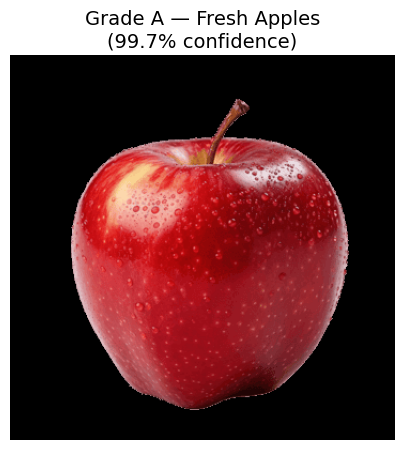


Overall grade verdict:
  Grade A: 100.0%  █████████████████████████████
  Grade C:   0.0%  

Top-5 specific classes:
  Grade A — Fresh Apples               99.75%
  Grade A — Fresh Tomato                0.11%
  Grade A — Fresh Tamto                 0.09%
  Grade C — Rotten Apples               0.03%
  Grade C — Rotten Tomato               0.01%


In [8]:
from google.colab import files
print('Pick a fruit image (jpg / png):')
imgs = files.upload()
for fname in imgs:
    print('\n=====', fname, '=====')
    predict_image(fname)